In [43]:
# Import các thư viện cần dùng
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
# Tải bộ dữ liệu iris
import seaborn as sns
from sklearn.datasets import load_iris

# Câu 1: Thống kê mô tả và đặc trưng

In [45]:
# Tải bộ dữ liệu Iris từ thư viện sklearn
iris = load_iris()

# Lấy dữ liệu đầu vào gồm 4 đặc trưng của hoa:
# sepal length, sepal width, petal length, petal width
X = iris.data

# Lấy nhãn của từng mẫu dữ liệu
# Mỗi nhãn là một số: 0, 1 hoặc 2
y = iris.target

# Lấy tên các cột đặc trưng
feature_names = iris.feature_names

# Lấy tên các loài hoa tương ứng với nhãn 0, 1, 2
target_names = iris.target_names

# Tạo DataFrame từ dữ liệu đặc trưng X
# Mỗi cột sẽ có tên lấy từ feature_names
df = pd.DataFrame(X, columns=feature_names)

# Thêm cột species vào DataFrame
# Chuyển nhãn dạng số trong y thành tên loài hoa tương ứng
df["species"] = [target_names[i] for i in y]

# Hiển thị 5 dòng đầu tiên của DataFrame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [46]:
# In số dòng và số cột của dataset
print("Số dòng, số cột của dataset:", df.shape)

# In kiểu dữ liệu của từng cột
print("\nKiểu dữ liệu của từng cột:")
print(df.dtypes)

# Kiểm tra nhanh thông tin tổng quan
print("\nThông tin tổng quan:")
df.info()

Số dòng, số cột của dataset: (150, 5)

Kiểu dữ liệu của từng cột:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

Thông tin tổng quan:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


Dataset Iris gồm 150 dòng và 5 cột.

Trong đó có 4 biến số:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

Cột species là biến phân loại, cho biết loài hoa tương ứng.

Các biến số đều có kiểu float, phù hợp để thực hiện thống kê mô tả, phân tích phân phối và tính tương quan.

In [47]:
# Chọn ra các cột số để tính toán thống kê
numeric_cols = df.select_dtypes(include=[np.number]).columns

print("Các biến số trong dataset:")
print(list(numeric_cols))

Các biến số trong dataset:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [48]:
# Tạo một danh sách rỗng để lưu kết quả thống kê của từng biến
stats_list = []

# Duyệt qua từng cột số
for col in numeric_cols:
    
    # Lấy dữ liệu của cột hiện tại
    data = df[col]
    
    # Tính Q1, Q3
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    
    # IQR = Q3 - Q1
    IQR = Q3 - Q1
    
    # Tạo dictionary chứa các thông số thống kê
    stats = {
        "variable": col,
        "mean": data.mean(),
        "median": data.median(),
        "mode": data.mode()[0],
        "var": data.var(),
        "std": data.std(),
        "min": data.min(),
        "max": data.max(),
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR
    }
    
    # Thêm kết quả vào danh sách
    stats_list.append(stats)

# Chuyển danh sách kết quả thành DataFrame
stats_df = pd.DataFrame(stats_list)

# Hiển thị bảng thống kê
stats_df

,variable,mean,median,mode,var,std,min,max,Q1,Q3,IQR
0,sepal length (cm),5.843333,5.80,5.0,0.685694,0.828066,4.3,7.9,5.1,6.4,1.3
1,sepal width (cm),3.057333,3.00,3.0,0.189979,0.435866,2.0,4.4,2.8,3.3,0.5
2,petal length (cm),3.758000,4.35,1.4,3.116278,1.765298,1.0,6.9,1.6,5.1,3.5
3,petal width (cm),1.199333,1.30,0.2,0.581006,0.762238,0.1,2.5,0.3,1.8,1.5


Từ bảng thống kê mô tả, ta có thể quan sát được xu hướng trung tâm và độ phân tán của từng biến.

Các biến petal length và petal width thường có độ phân tán lớn hơn so với sepal width. Điều này cho thấy kích thước cánh hoa có sự khác biệt rõ hơn giữa các mẫu.

IQR giúp đánh giá độ rộng của vùng dữ liệu chính, ít bị ảnh hưởng bởi giá trị ngoại lai hơn so với khoảng min-max.

In [49]:
# Tính mean của từng biến theo từng loài hoa
group_mean = df.groupby("species")[numeric_cols].mean()

print("Mean theo từng species:")
display(group_mean)

# Tính std của từng biến theo từng loài hoa
group_std = df.groupby("species")[numeric_cols].std()

print("Standard deviation theo từng species:")
display(group_std)

Mean theo từng species:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


Standard deviation theo từng species:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,0.352490,0.379064,0.173664,0.105386
versicolor,0.516171,0.313798,0.469911,0.197753
virginica,0.635880,0.322497,0.551895,0.274650


In [50]:
# Tính khoảng chênh lệch mean giữa các loài cho từng biến
# Công thức: max(mean theo loài) - min(mean theo loài)
mean_range = group_mean.max() - group_mean.min()

print("Độ chênh lệch mean giữa các loài cho từng biến:")
display(mean_range.sort_values(ascending=False))

# Biến có độ chênh lệch mean lớn nhất
most_different_variable = mean_range.idxmax()

print("Biến thể hiện sự khác biệt rõ nhất giữa các loài là:", most_different_variable)

Độ chênh lệch mean giữa các loài cho từng biến:


petal length (cm)    4.090
petal width (cm)     1.780
sepal length (cm)    1.582
sepal width (cm)     0.658
dtype: float64

Biến thể hiện sự khác biệt rõ nhất giữa các loài là: petal length (cm)


Khi nhóm dữ liệu theo species, ta thấy các biến liên quan đến petal, đặc biệt là petal length và petal width, có sự khác biệt trung bình rõ ràng giữa các loài.

Loài setosa thường khác biệt khá mạnh so với versicolor và virginica ở kích thước cánh hoa.

Vì vậy, petal length và petal width có thể là những đặc trưng quan trọng để phân loại loài hoa Iris.

# Câu 2: Phân phối xác suất

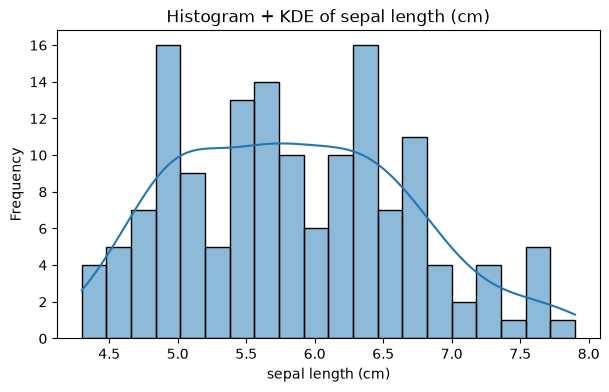

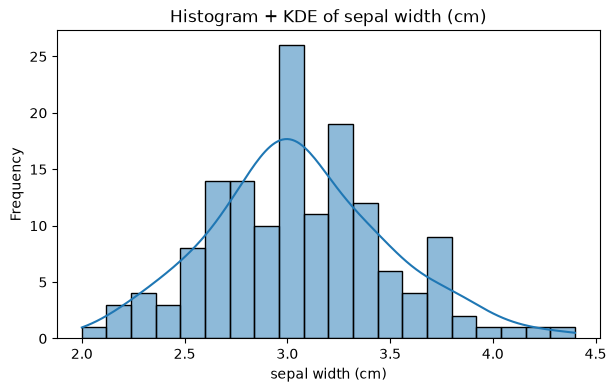

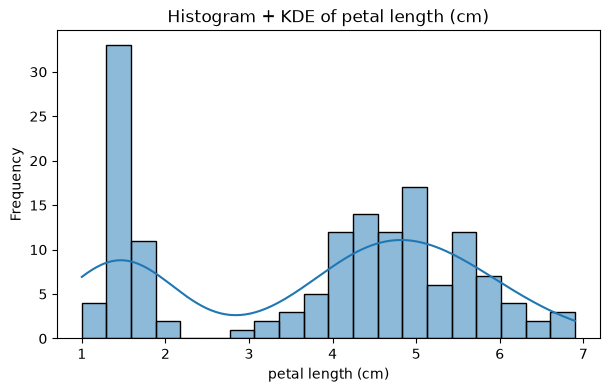

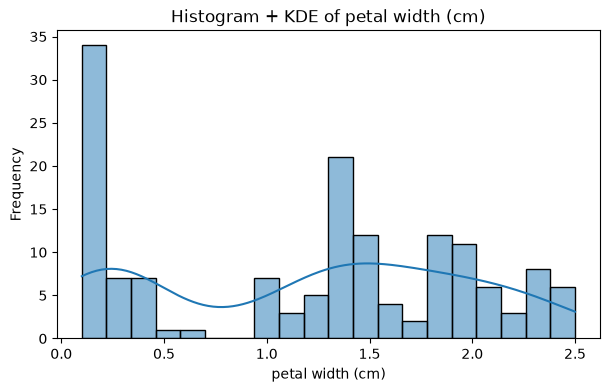

In [51]:
# Vẽ histogram + KDE cho từng biến số

for col in numeric_cols:
    
    plt.figure(figsize=(7, 4))
    
    # histplot vẽ histogram
    # kde=True thêm đường mật độ KDE
    sns.histplot(df[col], kde=True, bins=20)
    
    plt.title(f"Histogram + KDE of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Dựa trên histogram và KDE:

- sepal length có phân phối tương đối trải đều và hơi lệch nhẹ.
- sepal width có dạng gần phân phối chuẩn hơn so với các biến còn lại.
- petal length và petal width có xu hướng nhiều đỉnh do dữ liệu gồm nhiều loài hoa khác nhau.
- Các biến petal thể hiện sự tách nhóm rõ hơn, vì kích thước cánh hoa khác biệt giữa các loài.

Việc xuất hiện nhiều đỉnh trong phân phối có thể đến từ việc dataset gồm 3 nhóm species khác nhau.

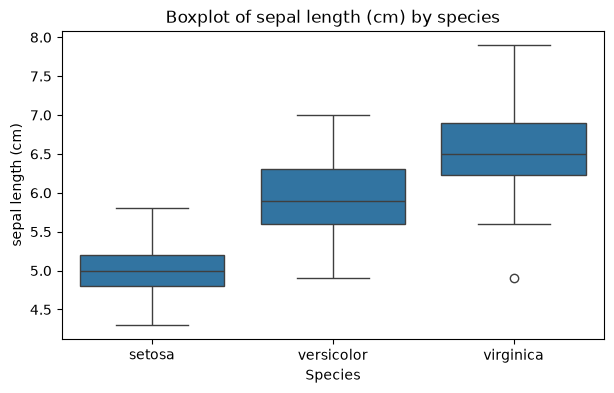

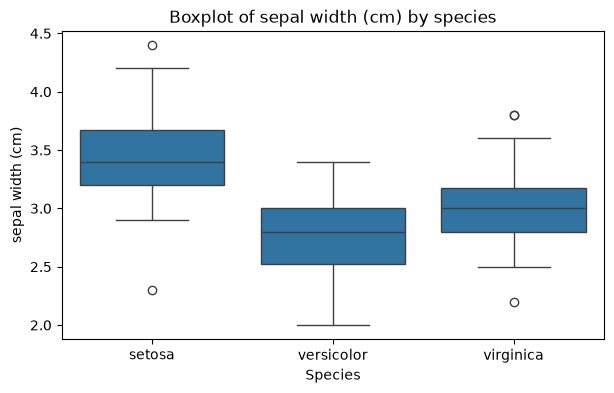

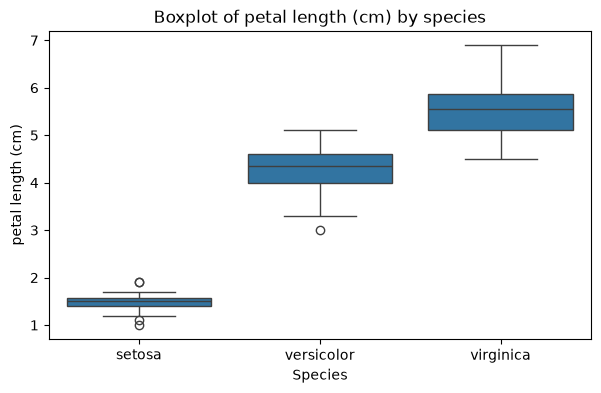

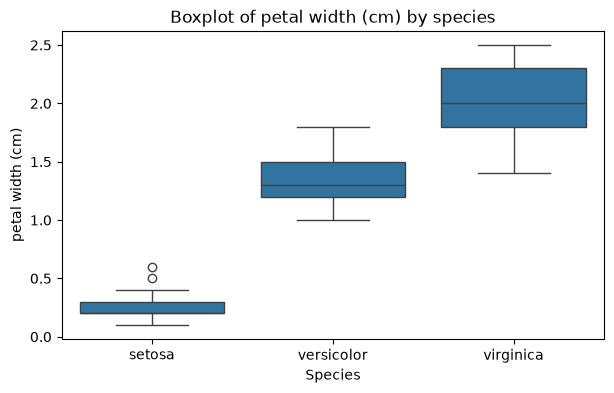

In [52]:
# Vẽ boxplot từng biến theo species

for col in numeric_cols:
    
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(data=df, x="species", y=col)
    
    plt.title(f"Boxplot of {col} by species")
    plt.xlabel("Species")
    plt.ylabel(col)
    plt.show()

Từ các boxplot, ta thấy petal length và petal width tách biệt rất rõ giữa các loài.

Đặc biệt, setosa có petal length và petal width nhỏ hơn đáng kể so với versicolor và virginica.

Trong khi đó, sepal width có sự chồng lấn nhiều hơn giữa các loài, nên biến này có khả năng phân biệt species kém hơn.

Biến được chọn: sepal width (cm)
Mean = 3.0573333333333337
Std = 0.4358662849366982


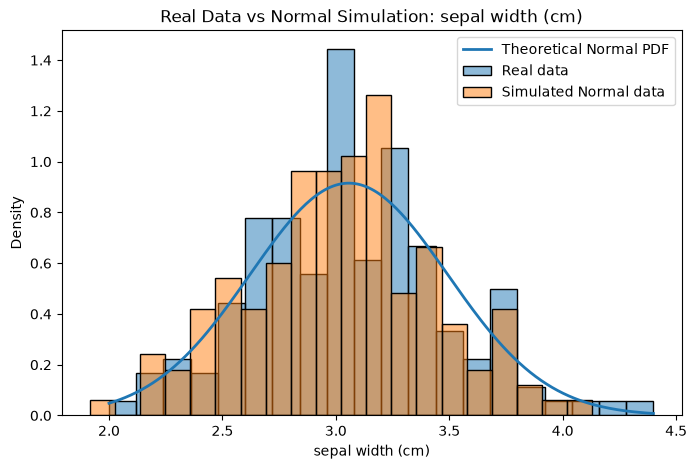

In [53]:
# Chọn một biến để mô phỏng phân phối Normal
chosen_col = "sepal width (cm)"

# Lấy dữ liệu thực tế của biến được chọn
real_data = df[chosen_col]

# Tính mean và std của dữ liệu thực tế
mu = real_data.mean()
sigma = real_data.std()

print("Biến được chọn:", chosen_col)
print("Mean =", mu)
print("Std =", sigma)

# Sinh dữ liệu giả lập từ phân phối Normal có cùng mean và std
np.random.seed(42)
simulated_data = np.random.normal(loc=mu, scale=sigma, size=len(real_data))

# Tạo trục x để vẽ đường PDF lý thuyết
x = np.linspace(real_data.min(), real_data.max(), 200)

# Công thức PDF của phân phối chuẩn
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Vẽ histogram dữ liệu thực tế dạng density
plt.figure(figsize=(8, 5))

sns.histplot(real_data, bins=20, stat="density", alpha=0.5, label="Real data")

# Vẽ histogram dữ liệu mô phỏng
sns.histplot(simulated_data, bins=20, stat="density", alpha=0.5, label="Simulated Normal data")

# Vẽ đường PDF lý thuyết
plt.plot(x, pdf, linewidth=2, label="Theoretical Normal PDF")

plt.title(f"Real Data vs Normal Simulation: {chosen_col}")
plt.xlabel(chosen_col)
plt.ylabel("Density")
plt.legend()
plt.show()

Khi so sánh dữ liệu thực tế của sepal width với phân phối Normal có cùng mean và std, ta thấy đường PDF lý thuyết mô tả tương đối tốt xu hướng trung tâm của dữ liệu.

Tuy nhiên, dữ liệu thực tế vẫn có thể lệch nhẹ hoặc có vài điểm khác biệt so với phân phối chuẩn hoàn hảo.

Điều này là bình thường vì dữ liệu thực tế thường chịu ảnh hưởng bởi nhiều yếu tố và không nhất thiết tuân theo đúng một phân phối Normal lý tưởng.

# Câu 3: Phân tích đa biến và tương quan

In [54]:
# Tính ma trận hiệp phương sai
cov_matrix = df[numeric_cols].cov()

print("Covariance matrix:")
display(cov_matrix)

# Tính ma trận tương quan
corr_matrix = df[numeric_cols].corr()

print("Correlation matrix:")
display(corr_matrix)

Covariance matrix:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),0.685694,-0.042434,1.274315,0.516271
sepal width (cm),-0.042434,0.189979,-0.329656,-0.121639
petal length (cm),1.274315,-0.329656,3.116278,1.295609
petal width (cm),0.516271,-0.121639,1.295609,0.581006


Correlation matrix:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


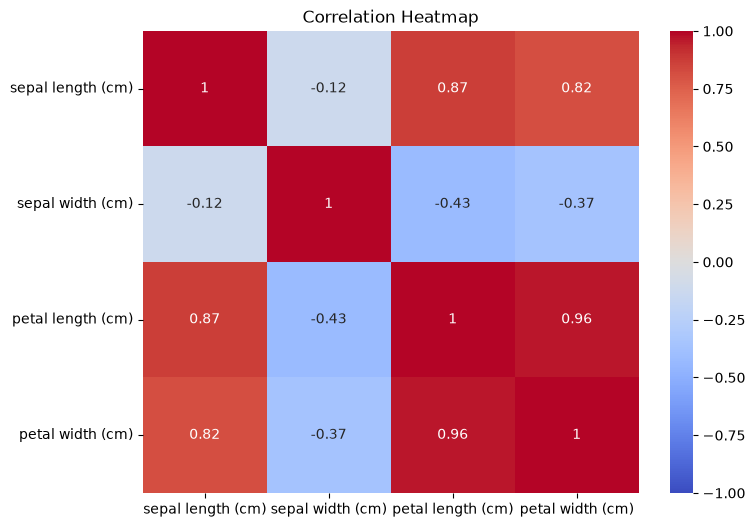

In [55]:
# Vẽ heatmap cho ma trận tương quan

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,       # Hiển thị giá trị correlation trên từng ô
    cmap="coolwarm",  # Màu thể hiện tương quan âm/dương
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap")
plt.show()

In [56]:
# Sao chép ma trận tương quan để xử lý
corr_abs = corr_matrix.abs().copy()

for col in corr_abs.columns:
    corr_abs.loc[col, col] = np.nan
# Tìm correlation tuyệt đối lớn nhất
max_corr_value = corr_abs.max().max()

# Lấy tên cặp biến có correlation mạnh nhất
max_corr_pair = corr_abs.stack().idxmax()

print("Cặp biến có tương quan mạnh nhất:", max_corr_pair)
print("Giá trị tương quan tuyệt đối:", max_corr_value)
print("Giá trị tương quan thực tế:", corr_matrix.loc[max_corr_pair[0], max_corr_pair[1]])

Cặp biến có tương quan mạnh nhất: ('petal length (cm)', 'petal width (cm)')
Giá trị tương quan tuyệt đối: 0.962865431402796
Giá trị tương quan thực tế: 0.962865431402796


Từ heatmap tương quan, cặp biến petal length và petal width thường có tương quan dương rất mạnh.

Điều này có nghĩa là khi chiều dài cánh hoa tăng thì chiều rộng cánh hoa cũng có xu hướng tăng.

Nếu hai biến có correlation rất cao, ví dụ lớn hơn 0.9, có thể xuất hiện dấu hiệu đa cộng tuyến.

Trong bài toán Machine Learning, đa cộng tuyến có thể gây khó khăn cho một số mô hình tuyến tính vì hai biến mang thông tin khá giống nhau.

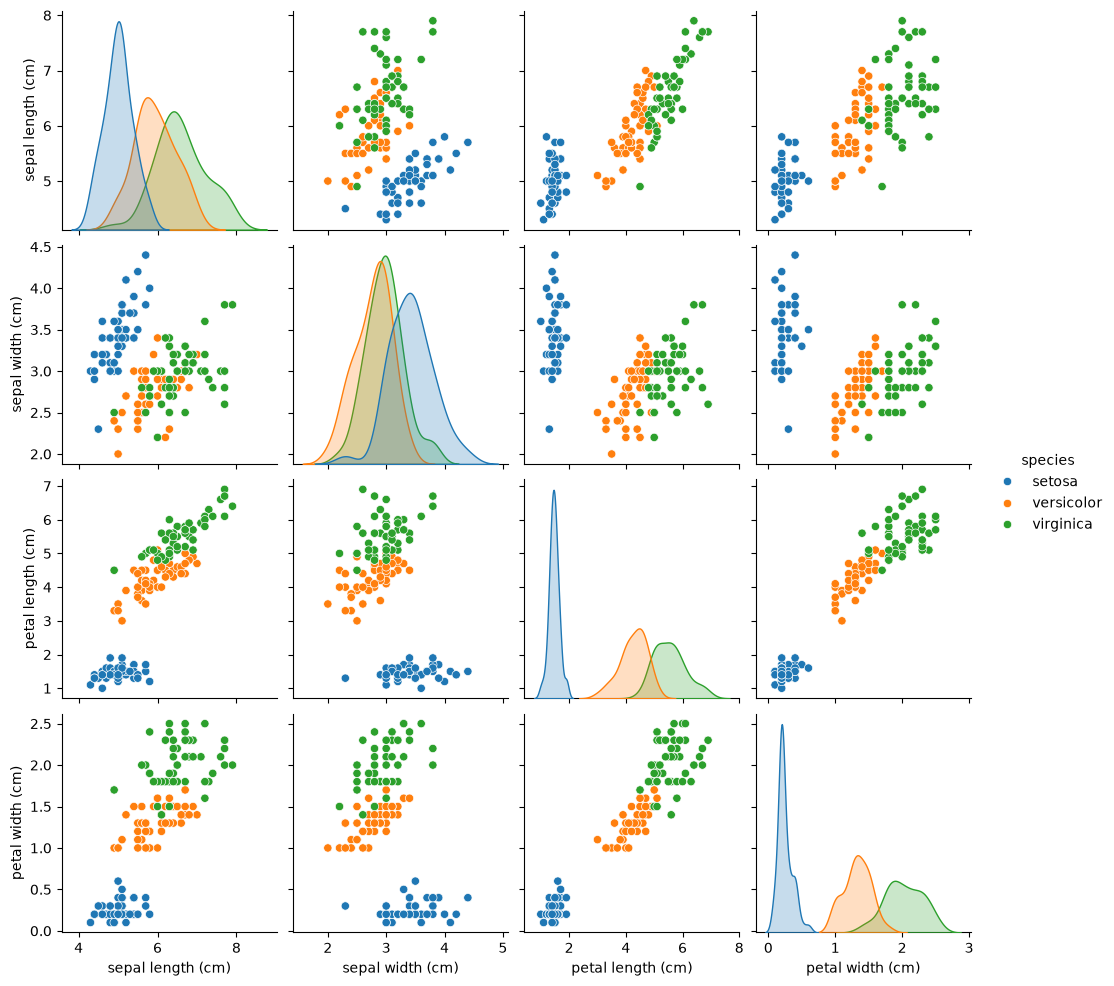

In [57]:
# Vẽ pairplot để xem quan hệ từng cặp biến
# hue="species" giúp tô màu theo từng loài hoa

sns.pairplot(df, hue="species", diag_kind="kde")

plt.show()

Pairplot cho thấy setosa thường tách biệt khá rõ khỏi hai loài còn lại, đặc biệt khi xét các biến petal length và petal width.

Versicolor và virginica có sự chồng lấn nhiều hơn, nhưng vẫn có xu hướng phân tách khi xét các biến cánh hoa.

Nhìn chung, petal length và petal width là hai biến hữu ích nhất trong việc phân biệt các loài Iris.

# Câu 4: Xác suất và định lý Bayes

In [58]:
# Xác suất mắc bệnh ban đầu
P_B = 0.01

# Độ nhạy của xét nghiệm: xác suất test dương tính nếu thật sự mắc bệnh
P_pos_given_B = 0.99

# Xác suất dương tính giả: test dương tính dù không mắc bệnh
P_pos_given_not_B = 0.05

# Xác suất không mắc bệnh
P_not_B = 1 - P_B

# Tính xác suất test dương tính toàn phần
# P(+) = P(+|B)P(B) + P(+|not B)P(not B)
P_pos = P_pos_given_B * P_B + P_pos_given_not_B * P_not_B

# Áp dụng định lý Bayes:
# P(B|+) = P(+|B)P(B) / P(+)
P_B_given_pos = P_pos_given_B * P_B / P_pos

print("P(B) =", P_B)
print("P(+|B) =", P_pos_given_B)
print("P(+|not B) =", P_pos_given_not_B)
print("P(+) =", P_pos)
print("P(B|+) =", P_B_given_pos)
print("P(B|+) rounded =", round(P_B_given_pos, 4))

P(B) = 0.01
P(+|B) = 0.99
P(+|not B) = 0.05
P(+) = 0.0594
P(B|+) = 0.16666666666666669
P(B|+) rounded = 0.1667


Mặc dù xét nghiệm có độ nhạy rất cao P(+|B) = 0.99, xác suất thật sự mắc bệnh sau khi test dương tính P(B|+) không quá cao.

Lý do là vì bệnh hiếm, chỉ có P(B) = 0.01.

Khi số người không mắc bệnh rất lớn, chỉ cần một tỉ lệ dương tính giả 0.05 cũng tạo ra nhiều ca test dương tính giả.

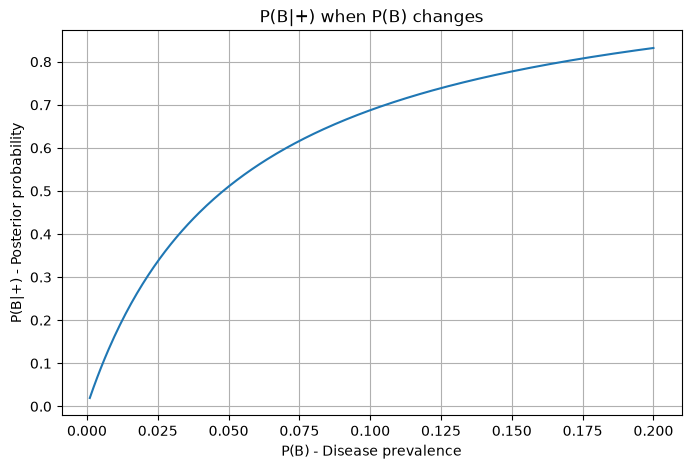

In [59]:
# Tạo nhiều giá trị P(B) từ 0.001 đến 0.2
P_B_values = np.linspace(0.001, 0.2, 300)

# Tính P(B|+) tương ứng với từng giá trị P(B)
P_B_given_pos_values = []

for P_B_current in P_B_values:
    
    # Xác suất không mắc bệnh
    P_not_B_current = 1 - P_B_current
    
    # Xác suất test dương tính toàn phần
    P_pos_current = (
        P_pos_given_B * P_B_current
        + P_pos_given_not_B * P_not_B_current
    )
    
    # Xác suất hậu nghiệm theo Bayes
    P_B_given_pos_current = (
        P_pos_given_B * P_B_current / P_pos_current
    )
    
    # Lưu kết quả
    P_B_given_pos_values.append(P_B_given_pos_current)

# Vẽ đồ thị
plt.figure(figsize=(8, 5))

plt.plot(P_B_values, P_B_given_pos_values)

plt.title("P(B|+) when P(B) changes")
plt.xlabel("P(B) - Disease prevalence")
plt.ylabel("P(B|+) - Posterior probability")
plt.grid(True)
plt.show()

Khi P(B) nhỏ, tức bệnh rất hiếm, xác suất P(B|+) vẫn có thể thấp dù xét nghiệm có độ nhạy cao.

Điều này phản trực giác vì nhiều người nghĩ rằng test dương tính nghĩa là gần như chắc chắn mắc bệnh.

Tuy nhiên, theo Bayes, ta phải xét cả tỉ lệ mắc bệnh ban đầu và tỉ lệ dương tính giả.

## Bonus: Navie Bayes

In [60]:
# Tập dữ liệu nhỏ để minh họa spam filter

emails = [
    "win money now",
    "free prize win",
    "cheap offer money",
    "meeting schedule today",
    "project meeting tomorrow",
    "please review project"
]

labels = [
    "spam",
    "spam",
    "spam",
    "not_spam",
    "not_spam",
    "not_spam"
]

# Tạo DataFrame cho dễ quan sát
spam_df = pd.DataFrame({
    "email": emails,
    "label": labels
})

spam_df

,email,label
0,win money now,spam
1,free prize win,spam
2,cheap offer money,spam
3,meeting schedule today,not_spam
4,project meeting tomorrow,not_spam
5,please review project,not_spam


In [61]:
# Hàm tách email thành các từ
def tokenize(text):
    return text.lower().split()

# Tạo vocabulary chứa tất cả từ khác nhau trong dataset
vocab = set()

for email in emails:
    words = tokenize(email)
    for word in words:
        vocab.add(word)

# Chuyển set thành list để dễ xử lý
vocab = sorted(list(vocab))

print("Vocabulary:")
print(vocab)

Vocabulary:
['cheap', 'free', 'meeting', 'money', 'now', 'offer', 'please', 'prize', 'project', 'review', 'schedule', 'today', 'tomorrow', 'win']


In [62]:
# Tính prior probability của từng lớp

total_emails = len(labels)

P_spam = labels.count("spam") / total_emails
P_not_spam = labels.count("not_spam") / total_emails

print("P(spam) =", P_spam)
print("P(not_spam) =", P_not_spam)

P(spam) = 0.5
P(not_spam) = 0.5


In [63]:
# Tách email theo từng lớp

spam_emails = spam_df[spam_df["label"] == "spam"]["email"]
not_spam_emails = spam_df[spam_df["label"] == "not_spam"]["email"]

# Gom tất cả từ trong email spam
spam_words = []

for email in spam_emails:
    spam_words.extend(tokenize(email))

# Gom tất cả từ trong email not spam
not_spam_words = []

for email in not_spam_emails:
    not_spam_words.extend(tokenize(email))

print("Spam words:")
print(spam_words)

print("\nNot spam words:")
print(not_spam_words)

Spam words:
['win', 'money', 'now', 'free', 'prize', 'win', 'cheap', 'offer', 'money']

Not spam words:
['meeting', 'schedule', 'today', 'project', 'meeting', 'tomorrow', 'please', 'review', 'project']


In [64]:
# Hàm tính xác suất P(word | class)
# Dùng Laplace smoothing để tránh xác suất bằng 0

def word_probability(word, words_in_class, vocab):
    
    # Số lần word xuất hiện trong class
    word_count = words_in_class.count(word)
    
    # Tổng số từ trong class
    total_words = len(words_in_class)
    
    # Số lượng từ khác nhau trong vocabulary
    vocab_size = len(vocab)
    
    # Laplace smoothing:
    # P(word|class) = (count(word) + 1) / (total_words + vocab_size)
    probability = (word_count + 1) / (total_words + vocab_size)
    
    return probability

In [65]:
# Hàm dự đoán xác suất spam cho một email

def predict_spam_probability(email):
    
    # Tách email thành các từ
    words = tokenize(email)
    
    # Bắt đầu với prior probability
    spam_score = P_spam
    not_spam_score = P_not_spam
    
    # Nhân xác suất của từng từ
    for word in words:
        
        # Chỉ xét những từ có trong vocabulary
        if word in vocab:
            spam_score *= word_probability(word, spam_words, vocab)
            not_spam_score *= word_probability(word, not_spam_words, vocab)
    
    # Chuẩn hóa để ra xác suất
    total_score = spam_score + not_spam_score
    
    P_spam_given_email = spam_score / total_score
    
    return P_spam_given_email

In [66]:
# Một vài email ví dụ để kiểm tra

test_emails = [
    "win free money",
    "project meeting today",
    "cheap project offer"
]

for email in test_emails:
    
    prob_spam = predict_spam_probability(email)
    
    print("Email:", email)
    print("P(spam | email) =", round(prob_spam, 4))
    
    if prob_spam >= 0.5:
        print("Prediction: spam")
    else:
        print("Prediction: not spam")
    

Email: win free money
P(spam | email) = 0.9474
Prediction: spam
Email: project meeting today
P(spam | email) = 0.0526
Prediction: not spam
Email: cheap project offer
P(spam | email) = 0.5714
Prediction: spam


Bộ lọc spam Naive Bayes hoạt động dựa trên xác suất xuất hiện của các từ trong từng lớp spam và not spam.

Các email chứa nhiều từ như win, free, money, cheap, offer thường có xác suất spam cao.

Các email chứa nhiều từ như meeting, project, schedule, review thường có xác suất not spam cao hơn.

Tuy nhiên, mô hình này chỉ là minh họa đơn giản.